# Customer Churn Prediction using Logistic Regression

## Objective

The objective of this project is to build an interpretable Logistic Regression model for customer churn prediction while emphasizing cost-sensitive decision making.

The workflow includes:

- Exploratory Data Analysis
- Feature Selection
- Multicollinearity Analysis
- Hyperparameter Optimization
- Threshold Optimization
- ROC Curve Analysis
- Precision-Recall Analysis
- Final Cost-sensitive Evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay , classification_report
from sklearn.preprocessing import StandardScaler


In [3]:
df=pd.read_csv("ChurnData.csv")
df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float64
 21  conf

In [5]:
df.columns

Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'cardten', 'voice', 'pager',
       'internet', 'callwait', 'confer', 'ebill', 'loglong', 'logtoll',
       'lninc', 'custcat', 'churn'],
      dtype='str')

In [6]:

y = df["churn"].astype(int)
X = df.drop("churn" , axis=1)
X

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,voice,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,1.0,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0


## Feature Selection

Some variables in the dataset are highly correlated or represent transformed versions of the same information. To reduce redundancy and improve model interpretability, these features are removed and the model is trained again for comparison.

In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

import pandas as pd
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})

importance['Abs_Coefficient'] = importance['Coefficient'].abs()
print(importance.sort_values(by='Abs_Coefficient', ascending=False))


     Feature  Coefficient  Abs_Coefficient
7   callcard    -0.956280         0.956280
0     tenure    -0.800021         0.800021
12   cardmon     0.719065         0.719065
15   tollten     0.513720         0.513720
5     employ    -0.486795         0.486795
1        age    -0.484445         0.484445
13   wiremon     0.420561         0.420561
21    confer    -0.362291         0.362291
16   cardten    -0.355159         0.355159
24   logtoll    -0.341642         0.341642
26   custcat     0.331968         0.331968
3     income    -0.309469         0.309469
22     ebill     0.288064         0.288064
25     lninc     0.277127         0.277127
8   wireless    -0.269121         0.269121
20  callwait    -0.240946         0.240946
10   tollmon     0.230902         0.230902
17     voice     0.189392         0.189392
11  equipmon     0.153572         0.153572
19  internet     0.131325         0.131325
18     pager    -0.110768         0.110768
2    address     0.108540         0.108540
6      equi

## Removing Redundant Features

Several variables contain nearly identical information or are mathematical transformations of existing features.

To improve interpretability and reduce multicollinearity, the following variables were removed:

- longten
- tollten
- cardten
- loglong
- logtoll
- lninc

In [8]:

columns_to_drop = [
    'longten', 'tollten', 'cardten',
    'loglong', 'logtoll',             # logarithm
    'lninc'
]

X = df.drop(columns=columns_to_drop)

if 'churn' in X.columns:
    X= X.drop(columns=['churn'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
importance['Abs_Coefficient'] = importance['Coefficient'].abs()

importance.sort_values(by='Abs_Coefficient', ascending=False)



,Feature,Coefficient,Abs_Coefficient
0,tenure,-0.818743,0.818743
7,callcard,-0.784320,0.784320
1,age,-0.493213,0.493213
10,tollmon,0.435950,0.435950
13,wiremon,0.412498,0.412498
5,employ,-0.398173,0.398173
12,cardmon,0.368220,0.368220
18,confer,-0.366198,0.366198
20,custcat,0.313463,0.313463
19,ebill,0.295223,0.295223


# Model Optimization: Addressing Multicollinearity

## 1. Problem Identification: Multicollinearity
In the initial modeling phase, several features exhibited high correlation with one another. This phenomenon, known as **Multicollinearity**, occurs when independent variables are highly predictable from each other.

### Consequences of Multicollinearity in our Logistic Regression:
*   **Inflated Coefficients:** Coefficients (weights) became unrealistically large (e.g., `cardmon` was ~0.72 and `callcard` was ~-0.95).
*   **Unstable Estimates:** The impact of variables shifted significantly when redundant features were added or removed.
*   **Poor Interpretability:** It became difficult to distinguish the "pure effect" of a single variable (e.g., the model struggled to separate the effect of `income` from its logarithmic transformation `lninc`).

## 2. Optimization Strategy
To improve the model's reliability and interpretability, I implemented a feature pruning strategy:
*   **Removed Redundant Aggregates:** Removed total cost columns (`longten`, `tollten`, `cardten`) that represented the same information as monthly behavior.
*   **Removed Logarithmic Transformations:** Elimmed `loglong`, `logtoll`, and `lninc` to prevent the model from being confused between raw values and their scales.
*   **Focused on Monthly Behavior:** Refined the feature set to focus strictly on monthly active usage patterns.

## 3. Comparative Analysis: Before vs. After

| Feature | Coefficient (Before) | Coefficient (After) | Observation |
| :--- | :---: | :---: | :--- |
| `cardmon` | **0.719** | **0.368** | Reduced from an inflated value to a realistic effect. |
| `income` | **-0.309** | **-0.022** | Revealed that income has negligible impact on churn. |
| `callcard` | **-0.956** | **-0.784** | Stabilized to a more realistic loyalty coefficient. |

## 4. Conclusion
The optimized model is now more **robust** and **interpretable**. By removing collinear variables, the coefficients now represent the **marginal effect** of each feature accurately. This allows for reliable business insights, such as identifying `tenure` and `callcard` as primary churn preventers, and `tollmon` and `wiremon` as primary churn drivers.


In [9]:
X

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,equipmon,cardmon,wiremon,voice,pager,internet,callwait,confer,ebill,custcat
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,0.00,15.25,35.7,1.0,1.0,0.0,1.0,1.0,0.0,4.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,50.10,23.25,64.9,1.0,1.0,1.0,1.0,1.0,1.0,4.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.00,23.75,0.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.00,14.25,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.00,12.75,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.00,12.50,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,0.00,32.75,64.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0


In [10]:

y

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    0
198    1
199    0
Name: churn, Length: 200, dtype: int64

In [11]:
X = X.values
y=y.values

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models= {"KNN":KNeighborsClassifier(),
         "Logistic Regression":LogisticRegression(C=0.01),
         "Decision Tree":DecisionTreeClassifier(),
         "Random Forest":RandomForestClassifier() }
for name,model in models.items():
    Score = cross_val_score(model,X_scaled , y,cv=5,scoring="roc_auc").mean()
    print(f"{name}(scoring:roc_auc) : {Score}")

KNN(scoring:roc_auc) : 0.7642530601582326
Logistic Regression(scoring:roc_auc) : 0.7937957157784744
Decision Tree(scoring:roc_auc) : 0.5965741155396328
Random Forest(scoring:roc_auc) : 0.760324302134647


## Model Selection

Several classification algorithms were evaluated using cross-validation.

Logistic Regression achieved the best overall performance while providing excellent interpretability, making it the final model for this project.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ----------------------------
# Train / Test Split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=2
)

# ----------------------------
# Pipeline
# ----------------------------

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=10000
    ))
])

# ----------------------------
# Hyperparameter Grid
# ----------------------------

params = [

    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },

    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },

    {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    }

]

# ----------------------------
# Repeated Stratified KFold
# ----------------------------

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# ----------------------------
# Grid Search
# ----------------------------

grid = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_train, y_train)

# ----------------------------
# Results
# ----------------------------

print("=" * 60)
print("Best CV Score:")
print(grid.best_score_)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Estimator:")
print(grid.best_estimator_)
print("=" * 60)

best_model = grid.best_estimator_

# ----------------------------
# Final Test Evaluation
# ----------------------------

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

Fitting 50 folds for each of 180 candidates, totalling 9000 fits
Best CV Score:
0.781439174352218

Best Parameters:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best Estimator:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=10000, penalty='l2',
                                    random_state=42, solver='liblinear'))])


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [26]:
import os
import pickle
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RepeatedStratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# Hyperparameter Grid
# --------------------------------------------------

params = [

    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },

    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },

    {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    }

]

# --------------------------------------------------
# Random States
# --------------------------------------------------

random_states = [0, 2, 4, 7, 10, 21, 30, 42, 50, 100]
# --------------------------------------------------
# Cache File
# --------------------------------------------------

cache_file = "grid_search_stability.pkl"

if os.path.exists(cache_file):

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    df_results = data["df_results"]
    summary = data["summary"]

    print("Loaded results from cache.")

else:

    # --------------------------------------------------
    # Run GridSearch
    # --------------------------------------------------

    results = []
    all_cv_results = []

    for rs in random_states:

        print("=" * 70)
        print(f"Train/Test Split Random State : {rs}")
        print("=" * 70)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.20,
            stratify=y,
            random_state=rs
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                random_state=42,
                max_iter=10000
            ))
        ])

        cv = RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=10,
            random_state=42
        )

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            return_train_score=False
        )

        grid.fit(X_train, y_train)

        results.append({

            "split_random_state": rs,
            "best_score": grid.best_score_,
            "best_params": str(grid.best_params_),
            "C": grid.best_params_["model__C"],
            "solver": grid.best_params_["model__solver"],
            "penalty": grid.best_params_["model__penalty"],
            "class_weight": str(grid.best_params_["model__class_weight"])

        })

        cv_results = pd.DataFrame(grid.cv_results_)
        cv_results["split_random_state"] = rs

        all_cv_results.append(cv_results)

    # --------------------------------------------------
    # Summary
    # --------------------------------------------------

    df_results = pd.DataFrame(results)

    all_cv_results = pd.concat(
        all_cv_results,
        ignore_index=True
    )

    all_cv_results["param_model__class_weight"] = (
        all_cv_results["param_model__class_weight"]
        .astype(str)
    )

    summary = (
        all_cv_results.groupby(
            [
                "param_model__C",
                "param_model__solver",
                "param_model__penalty",
                "param_model__class_weight",
                "param_model__l1_ratio"
            ],
            dropna=False
        )
        .agg(
            Mean_ROC_AUC=("mean_test_score", "mean"),
            Std_ROC_AUC=("mean_test_score", "std"),
            Max_ROC_AUC=("mean_test_score", "max"),
            Min_ROC_AUC=("mean_test_score", "min"),
            Count=("mean_test_score", "count")
        )
        .sort_values(
            by="Mean_ROC_AUC",
            ascending=False
        )
    )

    # --------------------------------------------------
    # Save Cache
    # --------------------------------------------------

    with open(cache_file, "wb") as f:
        pickle.dump(
            {
                "df_results": df_results,
                "summary": summary
            },
            f
        )

    print("Results saved to cache.")

# --------------------------------------------------
# Print Results
# --------------------------------------------------

print("\nResults\n")
print(df_results)

print("\nAverage Best CV Score\n")
print(df_results["best_score"].mean())

print("\nBest Parameter Frequency\n")
print(df_results["best_params"].value_counts())

print("\nC Frequency\n")
print(df_results["C"].value_counts())

print("\nSolver Frequency\n")
print(df_results["solver"].value_counts())

print("\nPenalty Frequency\n")
print(df_results["penalty"].value_counts())

print("\nClass Weight Frequency\n")
print(df_results["class_weight"].value_counts())

print("\n")
print("=" * 100)
#print("AVERAGE PERFORMANCE OF ALL HYPERPARAMETER COMBINATIONS")
#print("=" * 100)

#print(summary.head(30))

Loaded results from cache.

Results

   split_random_state  best_score  \
0                   0    0.768459   
1                   2    0.781439   
2                   4    0.794498   
3                   7    0.782672   
4                  10    0.747739   
5                  21    0.801937   
6                  30    0.796139   
7                  42    0.807729   
8                  50    0.780829   
9                 100    0.792543   

                                         best_params      C     solver  \
0  {'model__C': 0.001, 'model__class_weight': {0:...  0.001      lbfgs   
1  {'model__C': 0.01, 'model__class_weight': 'bal...  0.010  liblinear   
2  {'model__C': 0.01, 'model__class_weight': {0: ...  0.010      lbfgs   
3  {'model__C': 0.001, 'model__class_weight': {0:...  0.001  liblinear   
4  {'model__C': 0.001, 'model__class_weight': {0:...  0.001  liblinear   
5  {'model__C': 0.01, 'model__class_weight': {0: ...  0.010  liblinear   
6  {'model__C': 0.01, 'model__class_w

# Hyperparameter Stability Analysis

Selecting hyperparameters from a single train/test split may produce results that depend on a particular random partition of the dataset. To verify that the selected hyperparameters are not specific to one split, the tuning procedure is repeated across multiple train/test splits.

For each split:

- The dataset is divided using a different `random_state`.
- The test set remains completely unseen during hyperparameter optimization.
- Hyperparameters are selected using **GridSearchCV** with **Repeated Stratified K-Fold Cross Validation** (`5 folds × 10 repeats = 50 validation folds`).
- The best hyperparameters and the complete `cv_results_` are stored for later comparison.

---

## Why Repeated Stratified K-Fold?

A single K-Fold split can still introduce randomness because the validation folds are created only once.

Repeated Stratified K-Fold performs multiple independent stratified partitions of the training data, producing a more reliable estimate of each hyperparameter configuration by reducing the variance caused by a particular fold assignment.

---

## Why Evaluate Multiple Train/Test Splits?

The purpose of this experiment is **not** to obtain different hyperparameters for different random states. Instead, the goal is to verify that the hyperparameters selected in the main notebook remain consistent when the entire tuning procedure is repeated on multiple independent train/test splits.

Although the exact best configuration may occasionally differ (for example, `class_weight='balanced'` instead of `{0:1, 1:5}` or `C=0.001` instead of `0.01`), these configurations achieve nearly identical ROC-AUC scores. This indicates that the optimization is robust rather than being driven by a fortunate train/test split.

---

## Overall Results

Across 10 different train/test splits:

- `penalty='l2'` was selected in **all** runs.
- `{0:1, 1:5}` was selected in **9 out of 10** runs.
- `liblinear` was selected slightly more often than `lbfgs`.
- `C=0.01` and `C=0.001` were consistently the strongest regularization values.

The most frequently selected hyperparameter configuration was:

```python
{
    "C": 0.01,
    "solver": "liblinear",
    "penalty": "l2",
    "class_weight": {0:1, 1:5}
}
```

which appeared **3 times** as the exact best configuration.

---

## Average Performance of the Best Configurations

| C         | Solver        | Class Weight  | Mean ROC-AUC |
|-----------|---------------|---------------|-------------:|
| **0.01**  | **lbfgs**     | **{0:1,1:5}** | **0.783899** |
| **0.01**  | **liblinear** | **{0:1,1:5}** | **0.783889** |
| 0.01      | lbfgs         | {0:1,1:3}     | 0.783041 |
| 0.01      | lbfgs         | balanced      | 0.782994 |
| 0.01      | liblinear     | balanced      | 0.782871 |
| **0.001** | **liblinear** | **{0:1,1:5}** | **0.782494** |
| **0.001** | **lbfgs**     | **{0:1,1:5}** | **0.782195** |

The differences between these configurations are extremely small (less than **0.002 ROC-AUC**), indicating that several neighboring hyperparameter settings provide essentially equivalent performance.

---

## Conclusion

The stability analysis shows that the hyperparameters selected in the main notebook are not the result of a particular train/test split. Repeating the complete tuning procedure across multiple independent splits consistently identifies the same region of the hyperparameter space (`C≈0.001–0.01`, `L2` regularization, stronger weighting for the minority class(`"class_weight"="balanced"` or `"class_weight": {0:1, 1:5}`) or , and either `liblinear` or `lbfgs`).

Therefore, training the final model on the chosen split (e.g., `random_state=30`) and evaluating it on its untouched test set is well justified, since the selected hyperparameters are supported by repeated experiments rather than a single random partition of the data.

In [15]:
# Cache File
cache_file = "grid_search_stability.pkl"

if os.path.exists(cache_file):
    with open(cache_file,"rb") as f:
        cache=pickle.load(f)
    df_results=cache["df_results"]
    summary=cache["summary"]
    print("Loaded results from cache.")
else:
    # existing GridSearch code goes here (replace your current block)
    pass


Loaded results from cache.


In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Cost Function
# --------------------------------------------------

FN_COST = 30
FP_COST = 1

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

random_states = [10, 20, 30, 40, 50, 60, 2, 100, 500, 1000]

for rs in random_states:

    print("=" * 70)
    print(f"Random State : {rs}")
    print("=" * 70)

    # --------------------------------------------------
    # Train / Test Split
    # --------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        stratify=y,
        random_state=rs
    )

    # --------------------------------------------------
    # Model
    # --------------------------------------------------

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.01,
            solver="liblinear",
            penalty="l2",
            class_weight={0: 1, 1: 5},
            max_iter=10000,
            random_state=42
        ))
    ])

    # --------------------------------------------------
    # Cross Validation
    # --------------------------------------------------

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # --------------------------------------------------
    # Out-of-Fold Probabilities
    # --------------------------------------------------

    oof_prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    # --------------------------------------------------
    # Threshold Search
    # --------------------------------------------------

    best_threshold = None
    best_cost = np.inf

    for th in thresholds:

        pred = (oof_prob >= th).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            pred
        ).ravel()

        cost = FN_COST * fn + FP_COST * fp

        if cost < best_cost:
            best_cost = cost
            best_threshold = th

    # --------------------------------------------------
    # Final Model
    # --------------------------------------------------

    model.fit(X_train, y_train)

    test_prob = model.predict_proba(X_test)[:, 1]

    test_pred = (test_prob >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred
    ).ravel()

    test_cost = FN_COST * fn + FP_COST * fp

    results.append({

        "random_state": rs,
        "threshold": best_threshold,
        "cost_cv": best_cost,
        "cost_test": test_cost,
        "FN_test": fn,
        "FP_test": fp

    })

# --------------------------------------------------
# Results
# --------------------------------------------------

results = pd.DataFrame(results)

print("\nResults\n")
print(results)

print("\nAverage Threshold")
print(results["threshold"].mean())

print("\nThreshold Frequency")
print(results["threshold"].value_counts().sort_index())

print("\nAverage Test Cost")
print(results["cost_test"].mean())

print("\nStd Test Cost")
print(results["cost_test"].std())

print("\nAverage FN / FP")
print(results[["FN_test", "FP_test"]].mean())

print("\nStd FN / FP")
print(results[["FN_test", "FP_test"]].std())

Random State : 10
Random State : 20
Random State : 30


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Random State : 40


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Random State : 50
Random State : 60


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Random State : 2
Random State : 100


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Random State : 500
Random State : 1000

Results

   random_state  threshold  cost_cv  cost_test  FN_test  FP_test
0            10       0.14       94         39        0       39
1            20       0.39       94         50        1       20
2            30       0.23       85         40        0       40
3            40       0.32       67         56        1       26
4            50       0.19       92         35        0       35
5            60       0.20       89         39        0       39
6             2       0.17       94         42        0       42
7           100       0.40       85         60        1       30
8           500       0.43       51         87        2       27
9          1000       0.17       94         38        0       38

Average Threshold
0.264

Threshold Frequency
threshold
0.14    1
0.17    2
0.19    1
0.20    1
0.23    1
0.32    1
0.39    1
0.40    1
0.43    1
Name: count, dtype: int64

Average Test Cost
48.6

Std Test Cost
15.847888047167533

Avera

F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


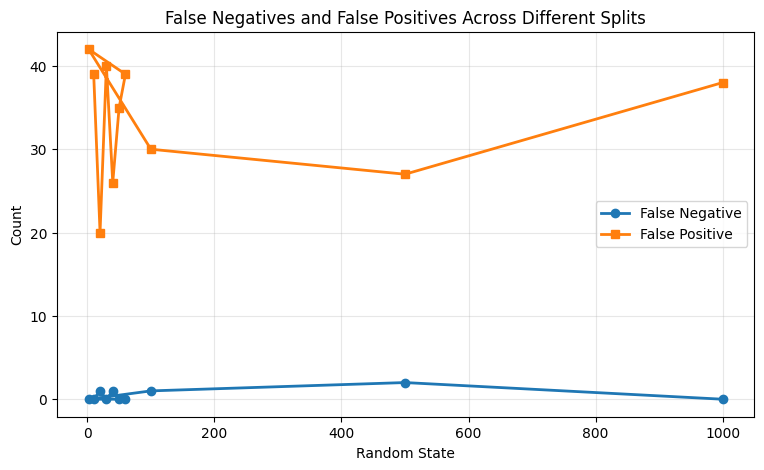

In [17]:
plt.figure(figsize=(9,5))

plt.plot(
    results["random_state"],
    results["FN_test"],
    marker="o",
    linewidth=2,
    label="False Negative"
)

plt.plot(
    results["random_state"],
    results["FP_test"],
    marker="s",
    linewidth=2,
    label="False Positive"
)

plt.xlabel("Random State")
plt.ylabel("Count")
plt.title("False Negatives and False Positives Across Different Splits")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

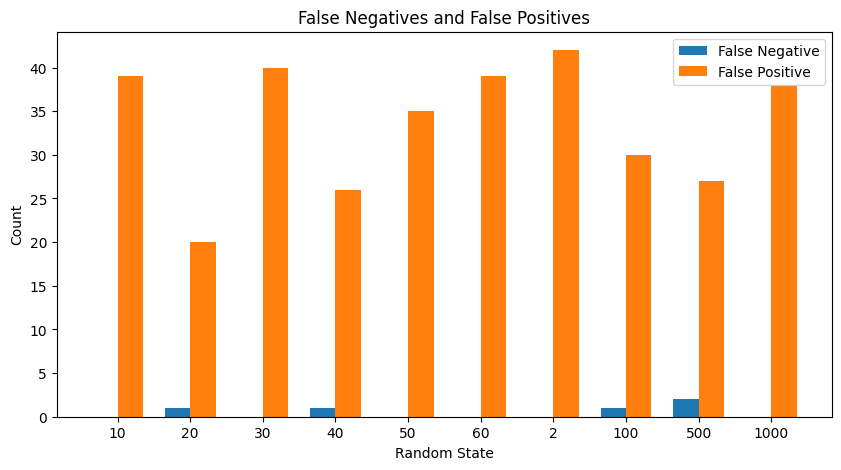

In [18]:
import numpy as np

x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    results["FN_test"],
    width,
    label="False Negative"
)

plt.bar(
    x + width/2,
    results["FP_test"],
    width,
    label="False Positive"
)

plt.xticks(
    x,
    results["random_state"]
)

plt.xlabel("Random State")
plt.ylabel("Count")
plt.title("False Negatives and False Positives")

plt.legend()

plt.show()

---------
training our model on train set

I evaluated the model over 10 different train/test splits. Despite different random states, the selected hyperparameters remained almost identical. This indicates that the optimization process is stable and the model is not highly sensitive to a particular data split.

For the final visualization, a single train/test split was selected to demonstrate the impact of threshold optimization on the trade-off between False Negatives and False Positives.

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        stratify=y,
        random_state=4
    )
model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.01,
            solver="liblinear",
            penalty="l2",
            class_weight={0: 1, 1: 5},
            max_iter=10000,
            random_state=42
        ))
    ])
model.fit(x_train, y_train)
y_hat = model.predict(x_test)
accuracy_score( y_test , y_hat )


F:\PY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.6833333333333333

# ROC Curve Evaluation

The Receiver Operating Characteristic (ROC) curve evaluates the ranking ability of the classifier across all possible decision thresholds.

Unlike Accuracy, ROC-AUC measures how well the model separates churn and non-churn customers independently of a fixed classification threshold.

auc_score : 0.8057455540355678


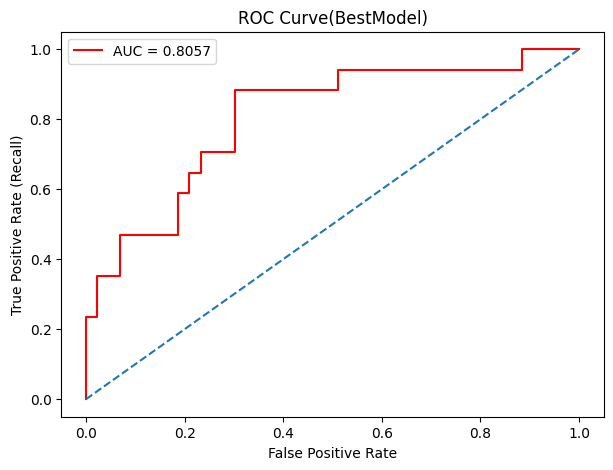

[       inf 0.88800267 0.86142897 0.82080458 0.81503365 0.79837089
 0.76366392 0.71784005 0.70954049 0.70950337 0.70070204 0.66012578
 0.64961101 0.59818808 0.54459575 0.44759111 0.44339473 0.19901518
 0.19336665 0.13977077]


In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
test_prob=model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, test_prob)

auc_score = roc_auc_score(y_test, test_prob)
print(f"auc_score : {auc_score}")
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}" , color="r")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve(BestModel)")
plt.legend()
plt.show()
print(thresholds)

# Precision–Recall Analysis

Because customer churn is an imbalanced classification problem, Precision–Recall curves provide additional insight into the trade-off between identifying churners and minimizing false alarms.

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_prob
)
print(precision.mean() )
print( recall.mean())
print(thresholds.mean())

0.5144420115248136
0.7155255544840888
0.5172800438678791


In [22]:
print(classification_report(y_test ,y_hat ))

              precision    recall  f1-score   support

           0       0.93      0.60      0.73        43
           1       0.47      0.88      0.61        17

    accuracy                           0.68        60
   macro avg       0.70      0.74      0.67        60
weighted avg       0.80      0.68      0.70        60



## Feature Importances

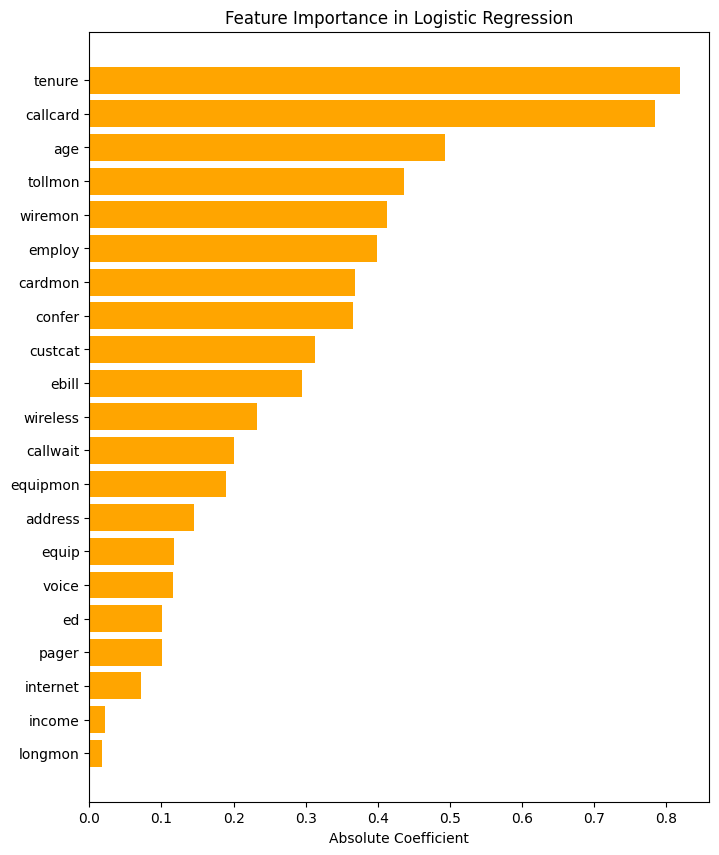

In [23]:

importance = importance.sort_values(
    "Abs_Coefficient",
    ascending=True
)
plt.figure(figsize=(8,10))
plt.barh(
    importance["Feature"],
    importance["Abs_Coefficient"],
    color="orange",
)
plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance in Logistic Regression")
plt.show()

# Threshold Optimization

The default decision threshold (0.50) is not always optimal for business applications.

Since False Negatives are significantly more expensive than False Positives in churn prediction, different probability thresholds are evaluated to identify a better operating point.

In [24]:
for t in [0.2  , 0.25 ,0.3, 0.35 ,0.39,0.4,0.5,0.6]:
    pred = (test_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test,pred).ravel()

    cost = fn*30 + fp

    print(t, tn, fp, fn, tp, cost)

0.2 6 37 1 16 67
0.25 12 31 1 16 61
0.3 13 30 1 16 60
0.35 16 27 1 16 57
0.39 18 25 1 16 55
0.4 19 24 1 16 54
0.5 26 17 2 15 77
0.6 31 12 5 12 162


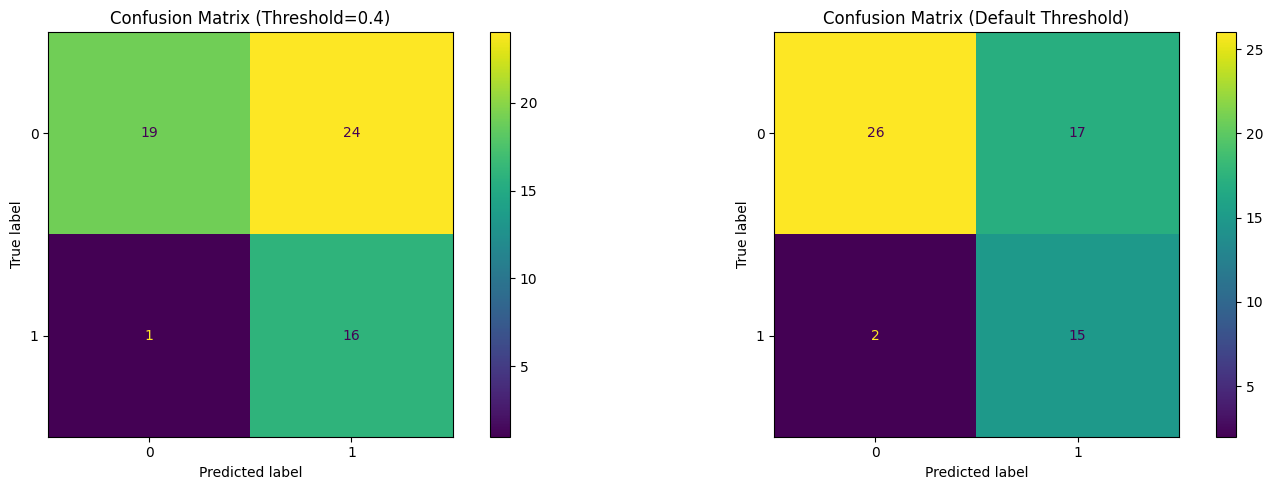

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

prob = model.predict_proba(x_test)[:, 1]
pred = (prob >= 0.4).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax[0])
ax[0].set_title("Confusion Matrix (Threshold=0.4)")

ConfusionMatrixDisplay.from_predictions(y_test, y_hat, ax=ax[1])
ax[1].set_title("Confusion Matrix (Default Threshold)")

plt.tight_layout()
plt.show()


### Threshold Comparison

Compared with the default threshold (0.50), using the optimized threshold decreases the number of False Negatives while increasing False Positives.

This trade-off is desirable because failing to identify a customer who is likely to churn is substantially more costly than contacting an additional customer unnecessarily.

# Business Interpretation

The optimized Logistic Regression model is not designed to maximize accuracy alone.

Instead, it prioritizes reducing False Negatives because missing a customer who is likely to churn is considerably more expensive than contacting an additional customer.

Threshold optimization therefore produces a model that better aligns with business objectives than the default decision threshold.

# Conclusion

- Best Model:
    - Logistic Regression

- Best Hyperparameters:
    - C = 0.01
    - Solver = liblinear
    - Penalty = L2
    - Class Weight = {0:1,1:5}

- ROC-AUC = 0.805

- Threshold Optimization reduced False Negatives while keeping False Positives acceptable.

- Cost-sensitive evaluation was used because missing a churn customer is more expensive than contacting an extra customer.